### Intalación y implementacion

Este bloque instala y carga las librerías necesarias. Se usa MedMNIST para descargar PathMNIST, PyTorch para la CNN, torchvision para ResNet18 pre-entrenada, y sklearn para calcular métricas.

In [1]:

import hashlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import medmnist
from medmnist import INFO

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

c:\Desarrollo\Proyectos\Activos\pathmnist-medical-vision-ml\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuracion reproducioble del experimento

Este bloque fija la semilla para que el experimento sea reproducible. También define que usaremos PathMNIST, resolución 28x28, y detecta automáticamente si el cuadernillo puede usar GPU.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_FLAG = "pathmnist"
SIZE = 128
# Antes en 256, probar 16 y 32
BATCH_SIZE = 64
NUM_WORKERS = 2

info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

n_classes = len(info["label"])
class_names = [info["label"][str(i)] for i in range(n_classes)]

print("Dispositivo:", DEVICE)
print("Dataset:", DATA_FLAG)
print("Resolución:", SIZE, "x", SIZE)
print("Número de clases:", n_classes)
print("Clases:", class_names)

Dispositivo: cuda
Dataset: pathmnist
Resolución: 128 x 128
Número de clases: 9
Clases: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']


### Definicion formal de hold-out

Este bloque deja documentado el diseño experimental. Training se usa para aprender, validation para decidir cuál época/modelo funciona mejor, y test queda reservado para la evaluación final.

Esto es exactamente el hold-out: dividir los datos en subconjuntos separados. En este trabajo no conviene hacer train_test_split manual, porque PathMNIST ya viene con particiones oficiales.

In [3]:
split_sizes = info["n_samples"]

holdout_df = pd.DataFrame({
    "Conjunto": ["Training", "Validation", "Test"],
    "Split oficial MedMNIST": ["train", "val", "test"],
    "Cantidad de imágenes": [
        split_sizes["train"],
        split_sizes["val"],
        split_sizes["test"]
    ],
    "Uso experimental": [
        "Entrenar los pesos del modelo",
        "Elegir el mejor modelo durante el entrenamiento",
        "Evaluar el rendimiento final una sola vez"
    ]
})

display(holdout_df)

,Conjunto,Split oficial MedMNIST,Cantidad de imágenes,Uso experimental
0,Training,train,89996,Entrenar los pesos del modelo
1,Validation,val,10004,Elegir el mejor modelo durante el entrenamiento
2,Test,test,7180,Evaluar el rendimiento final una sola vez




Este bloque carga los tres conjuntos oficiales. Al entrenamiento se le aplican aumentos leves de datos: giros, rotaciones y volteos. A validación y test no se les aplica aumento, porque esos conjuntos deben medir el rendimiento real del modelo.

La normalización usada es la de ImageNet porque el modelo ResNet18 viene pre-entrenado con ImageNet. Esto es importante para que la entrada tenga una escala compatible con los pesos pre-entrenados.

In [4]:
train_transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7405, 0.5330, 0.7058],
        std=[0.1532, 0.2074, 0.1487]
    )
])

val_test_transform = transforms.Compose([
    # transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7405, 0.5330, 0.7058],
        std=[0.1532, 0.2074, 0.1487]
    )
])

train_dataset = DataClass(
    split="train",
    transform=train_transform,
    download=True,
    size=SIZE
)

val_dataset = DataClass(
    split="val",
    transform=val_test_transform,
    download=True,
    size=SIZE
)

test_dataset = DataClass(
    split="test",
    transform=val_test_transform,
    download=True,
    size=SIZE
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 89996
Validation: 10004
Test: 7180


---

### EDA global del dataset

 


In [5]:
DATA_FLAG = "pathmnist"
DATASET_NAME = "PathMNIST"
TARGET_RESOLUTION = "128x128"
EXPECTED_TASK = "multi-class"
EXPECTED_CHANNELS = 3
EXPECTED_NUM_CLASSES = 9
EXPECTED_IMAGE_SHAPE = (128, 128, 3)


info = INFO[DATA_FLAG]
task = info["task"]
n_channels = info["n_channels"]
n_classes = len(info["label"])
class_labels = info["label"]
n_samples = info["n_samples"]

datasets = {
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
}

classes_df = pd.DataFrame({
    "class_id": [int(class_id) for class_id in class_labels.keys()],
    "class_name": list(class_labels.values())
}).sort_values("class_id").reset_index(drop=True)
expected_split_sizes = {
    "train": n_samples["train"],
    "validation": n_samples["val"],
    "test": n_samples["test"],
}

split_size_df = pd.DataFrame([
    {
        "split": split_name,
        "num_images_observed": len(dataset),
        "num_images_expected": expected_split_sizes[split_name],
        "matches_expected": len(dataset) == expected_split_sizes[split_name],
        "image_shape": dataset.imgs.shape[1:],
        "label_shape": dataset.labels.shape,
    }
    for split_name, dataset in datasets.items()
])

class_id_to_name = dict(zip(classes_df["class_id"], classes_df["class_name"]))

display(split_size_df)

assert task == EXPECTED_TASK
assert n_channels == EXPECTED_CHANNELS
assert n_classes == EXPECTED_NUM_CLASSES

for split_name, dataset in datasets.items():
    assert len(dataset) == expected_split_sizes[split_name]
    assert dataset.imgs.shape[1:] == EXPECTED_IMAGE_SHAPE
    assert dataset.labels.shape[0] == dataset.imgs.shape[0]

print("Carga y validaciones mínimas completadas correctamente.")

,split,num_images_observed,num_images_expected,matches_expected,image_shape,label_shape
0,train,89996,89996,True,"(128, 128, 3)","(89996, 1)"
1,validation,10004,10004,True,"(128, 128, 3)","(10004, 1)"
2,test,7180,7180,True,"(128, 128, 3)","(7180, 1)"


Carga y validaciones mínimas completadas correctamente.


In [6]:
def inspect_dataset_structure(dataset, split_name):
    images = dataset.imgs
    labels = dataset.labels
    return {
        "split": split_name,
        "num_images": images.shape[0],
        "image_height": images.shape[1],
        "image_width": images.shape[2],
        "num_channels": images.shape[3],
        "image_dtype": str(images.dtype),
        "label_shape": labels.shape,
        "label_dtype": str(labels.dtype),
        "pixel_min": int(images.min()),
        "pixel_max": int(images.max()),
    }

structure_df = pd.DataFrame([
    inspect_dataset_structure(dataset, split_name)
    for split_name, dataset in datasets.items()
])

display(structure_df)


,split,num_images,image_height,image_width,num_channels,image_dtype,label_shape,label_dtype,pixel_min,pixel_max
0,train,89996,128,128,3,uint8,"(89996, 1)",uint8,0,255
1,validation,10004,128,128,3,uint8,"(10004, 1)",uint8,0,255
2,test,7180,128,128,3,uint8,"(7180, 1)",uint8,0,255


In [7]:
def compute_class_distribution(dataset, split_name, class_id_to_name):
    labels = dataset.labels.reshape(-1).astype(int)
    unique_labels, counts = np.unique(labels, return_counts=True)
    total = labels.shape[0]

    rows = []
    for class_id, count in zip(unique_labels, counts):
        rows.append({
            "split": split_name,
            "class_id": int(class_id),
            "class_name": class_id_to_name[int(class_id)],
            "count": int(count),
            "percentage": 100 * count / total,
        })

    return pd.DataFrame(rows)

class_distribution_df = pd.concat([
    compute_class_distribution(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

class_count_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

class_percentage_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="percentage"
).reset_index()

for column in ["train", "validation", "test"]:
    class_percentage_pivot[column] = class_percentage_pivot[column].round(2)

imbalance_df = class_distribution_df.groupby("split").agg(
    min_class_count=("count", "min"),
    max_class_count=("count", "max"),
    mean_class_count=("count", "mean"),
).reset_index()
imbalance_df["max_to_min_ratio"] = (
    imbalance_df["max_class_count"] / imbalance_df["min_class_count"]
).round(3)

split_difference_df = class_percentage_pivot[["class_id", "class_name"]].copy()
split_difference_df["validation_minus_train"] = (
    class_percentage_pivot["validation"] - class_percentage_pivot["train"]
).round(2)
split_difference_df["test_minus_train"] = (
    class_percentage_pivot["test"] - class_percentage_pivot["train"]
).round(2)

print("Conteos por clase y split")
display(class_count_pivot)
print("Porcentajes por clase y split")
display(class_percentage_pivot)
print("Resumen de desbalance")
display(imbalance_df)
print("Diferencias porcentuales respecto a train")
display(split_difference_df)


Conteos por clase y split


split,class_id,class_name,test,train,validation
0,0,adipose,1338,9366,1041
1,1,background,847,9509,1057
2,2,debris,339,10360,1152
3,3,lymphocytes,634,10401,1156
4,4,mucus,1035,8006,890
5,5,smooth muscle,592,12182,1354
6,6,normal colon mucosa,741,7886,877
7,7,cancer-associated stroma,421,9401,1045
8,8,colorectal adenocarcinoma epithelium,1233,12885,1432


Porcentajes por clase y split


split,class_id,class_name,test,train,validation
0,0,adipose,18.64,10.41,10.41
1,1,background,11.80,10.57,10.57
2,2,debris,4.72,11.51,11.52
3,3,lymphocytes,8.83,11.56,11.56
4,4,mucus,14.42,8.90,8.90
5,5,smooth muscle,8.25,13.54,13.53
6,6,normal colon mucosa,10.32,8.76,8.77
7,7,cancer-associated stroma,5.86,10.45,10.45
8,8,colorectal adenocarcinoma epithelium,17.17,14.32,14.31


Resumen de desbalance


,split,min_class_count,max_class_count,mean_class_count,max_to_min_ratio
0,test,339,1338,797.777778,3.947
1,train,7886,12885,9999.555556,1.634
2,validation,877,1432,1111.555556,1.633


Diferencias porcentuales respecto a train


split,class_id,class_name,validation_minus_train,test_minus_train
0,0,adipose,0.00,8.23
1,1,background,0.00,1.23
2,2,debris,0.01,-6.79
3,3,lymphocytes,0.00,-2.73
4,4,mucus,0.00,5.52
5,5,smooth muscle,-0.01,-5.29
6,6,normal colon mucosa,0.01,1.56
7,7,cancer-associated stroma,0.00,-4.59
8,8,colorectal adenocarcinoma epithelium,-0.01,2.85


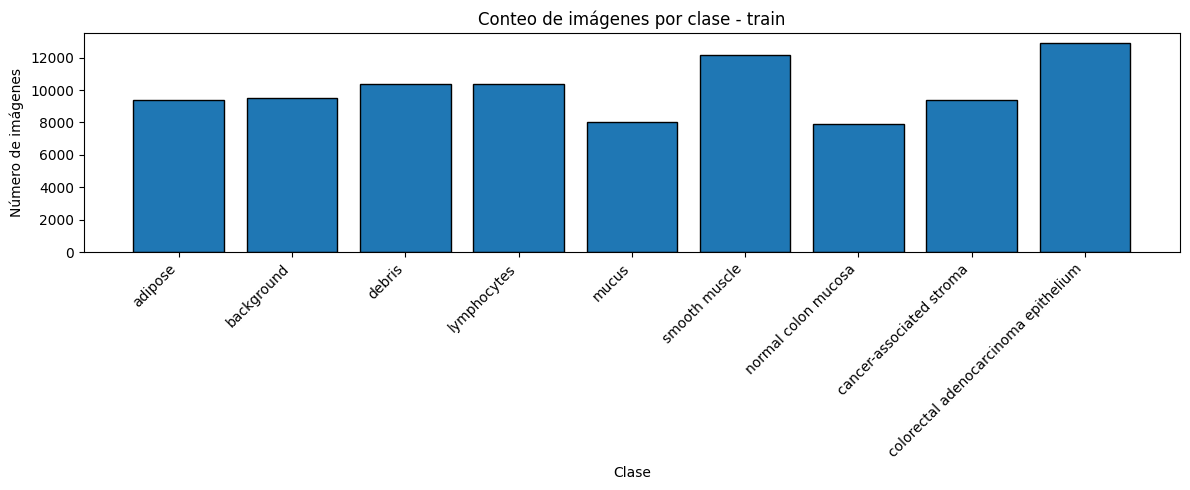

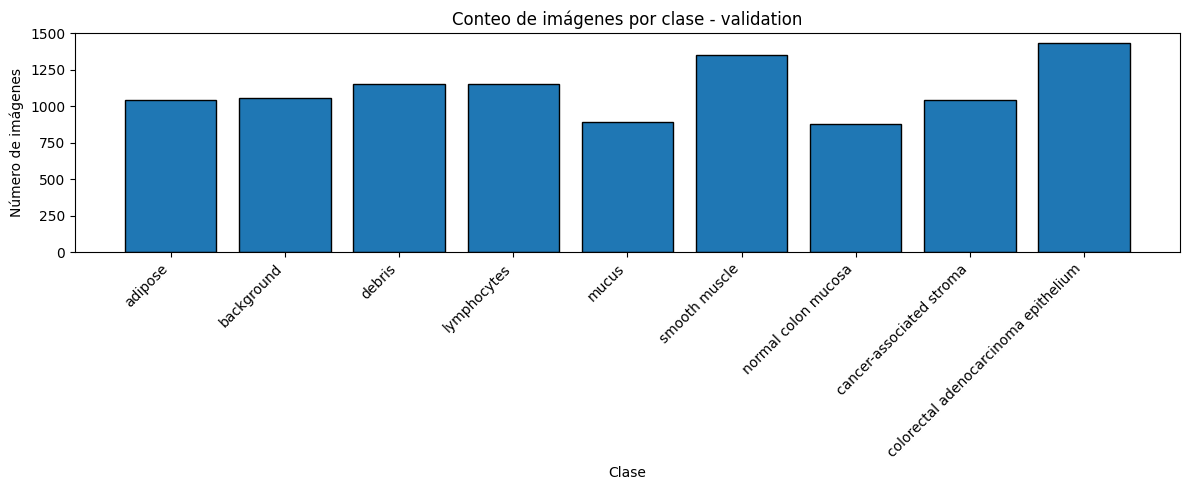

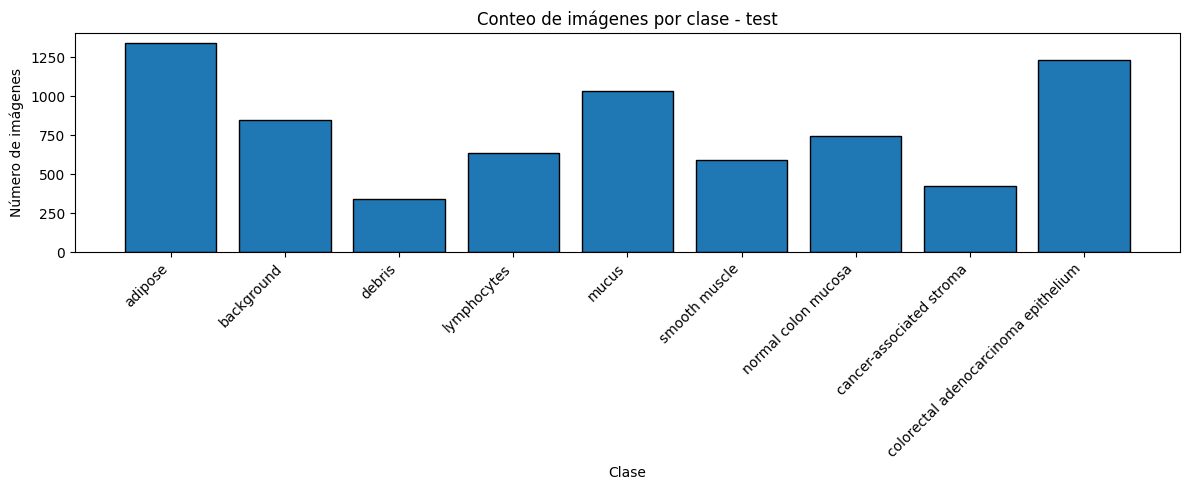

In [8]:
for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]

    plt.figure(figsize=(12, 5))
    plt.bar(split_data["class_name"], split_data["count"], edgecolor="black")
    plt.title(f"Conteo de imágenes por clase - {split_name}")
    plt.xlabel("Clase")
    plt.ylabel("Número de imágenes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

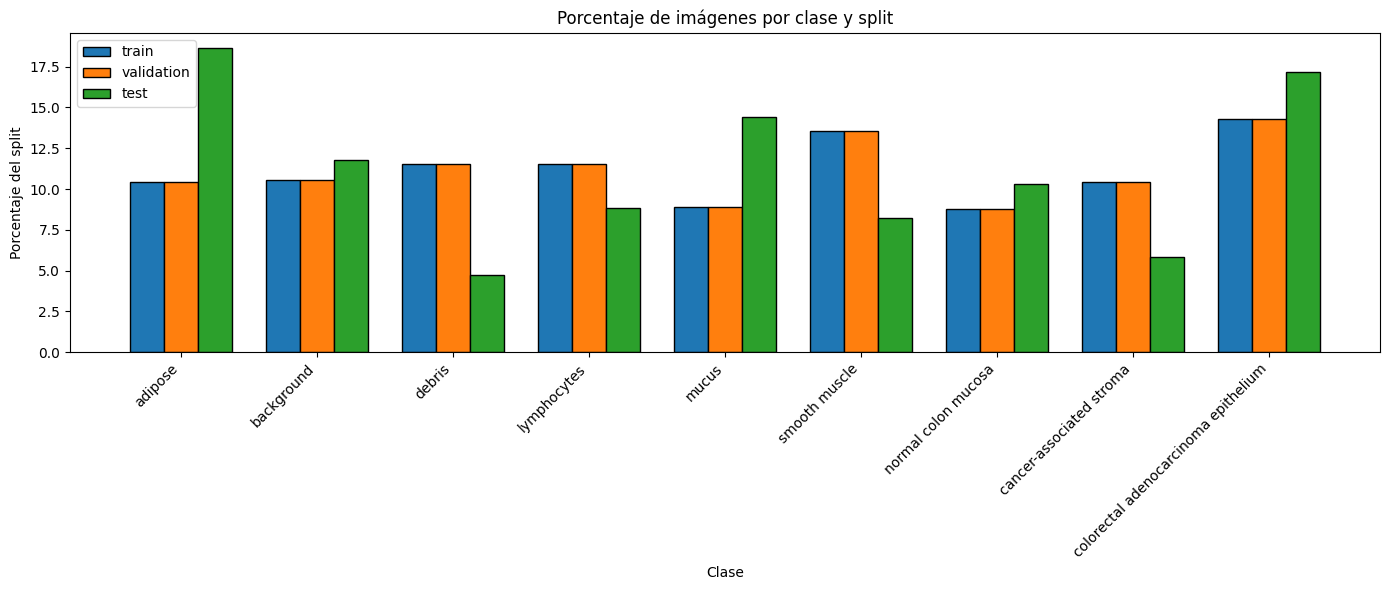

In [9]:
x = np.arange(len(class_percentage_pivot["class_name"]))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, class_percentage_pivot["train"], width, label="train", edgecolor="black")
plt.bar(x, class_percentage_pivot["validation"], width, label="validation", edgecolor="black")
plt.bar(x + width, class_percentage_pivot["test"], width, label="test", edgecolor="black")
plt.title("Porcentaje de imágenes por clase y split")
plt.xlabel("Clase")
plt.ylabel("Porcentaje del split")
plt.xticks(x, class_percentage_pivot["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

x = np.arange(len(split_difference_df["class_name"]))
width = 0.35



In [10]:
visual_coverage_df = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

visual_coverage_df["min_available_across_splits"] = visual_coverage_df[
    ["train", "validation", "test"]
].min(axis=1)

display(visual_coverage_df)

split,class_id,class_name,test,train,validation,min_available_across_splits
0,0,adipose,1338,9366,1041,1041
1,1,background,847,9509,1057,847
2,2,debris,339,10360,1152,339
3,3,lymphocytes,634,10401,1156,634
4,4,mucus,1035,8006,890,890
5,5,smooth muscle,592,12182,1354,592
6,6,normal colon mucosa,741,7886,877,741
7,7,cancer-associated stroma,421,9401,1045,421
8,8,colorectal adenocarcinoma epithelium,1233,12885,1432,1233


In [11]:
def sample_indices_by_class(dataset, class_id, n_samples=3, seed=42):
    labels = dataset.labels.reshape(-1).astype(int)
    candidate_indices = np.where(labels == class_id)[0]
    rng = np.random.default_rng(seed)
    selected = rng.choice(
        candidate_indices,
        size=min(n_samples, len(candidate_indices)),
        replace=False,
    )
    return selected


def plot_all_classes_across_splits(datasets, class_id_to_name, seed=42):
    class_ids = sorted(class_id_to_name.keys())
    split_names = ["train", "validation", "test"]

    fig, axes = plt.subplots(
        nrows=len(class_ids),
        ncols=len(split_names),
        figsize=(9, 2.1 * len(class_ids)),
    )

    for row_idx, class_id in enumerate(class_ids):
        for col_idx, split_name in enumerate(split_names):
            dataset = datasets[split_name]
            selected_idx = sample_indices_by_class(dataset, class_id, n_samples=1, seed=seed + row_idx + col_idx)[0]
            image = dataset.imgs[selected_idx]

            ax = axes[row_idx, col_idx]
            ax.imshow(image)
            ax.axis("off")
            if row_idx == 0:
                ax.set_title(split_name)
            if col_idx == 0:
                ax.set_ylabel(f"{class_id}: {class_id_to_name[class_id]}", rotation=0, ha="right", va="center")

    fig.suptitle("Muestra visual por clase y split", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()




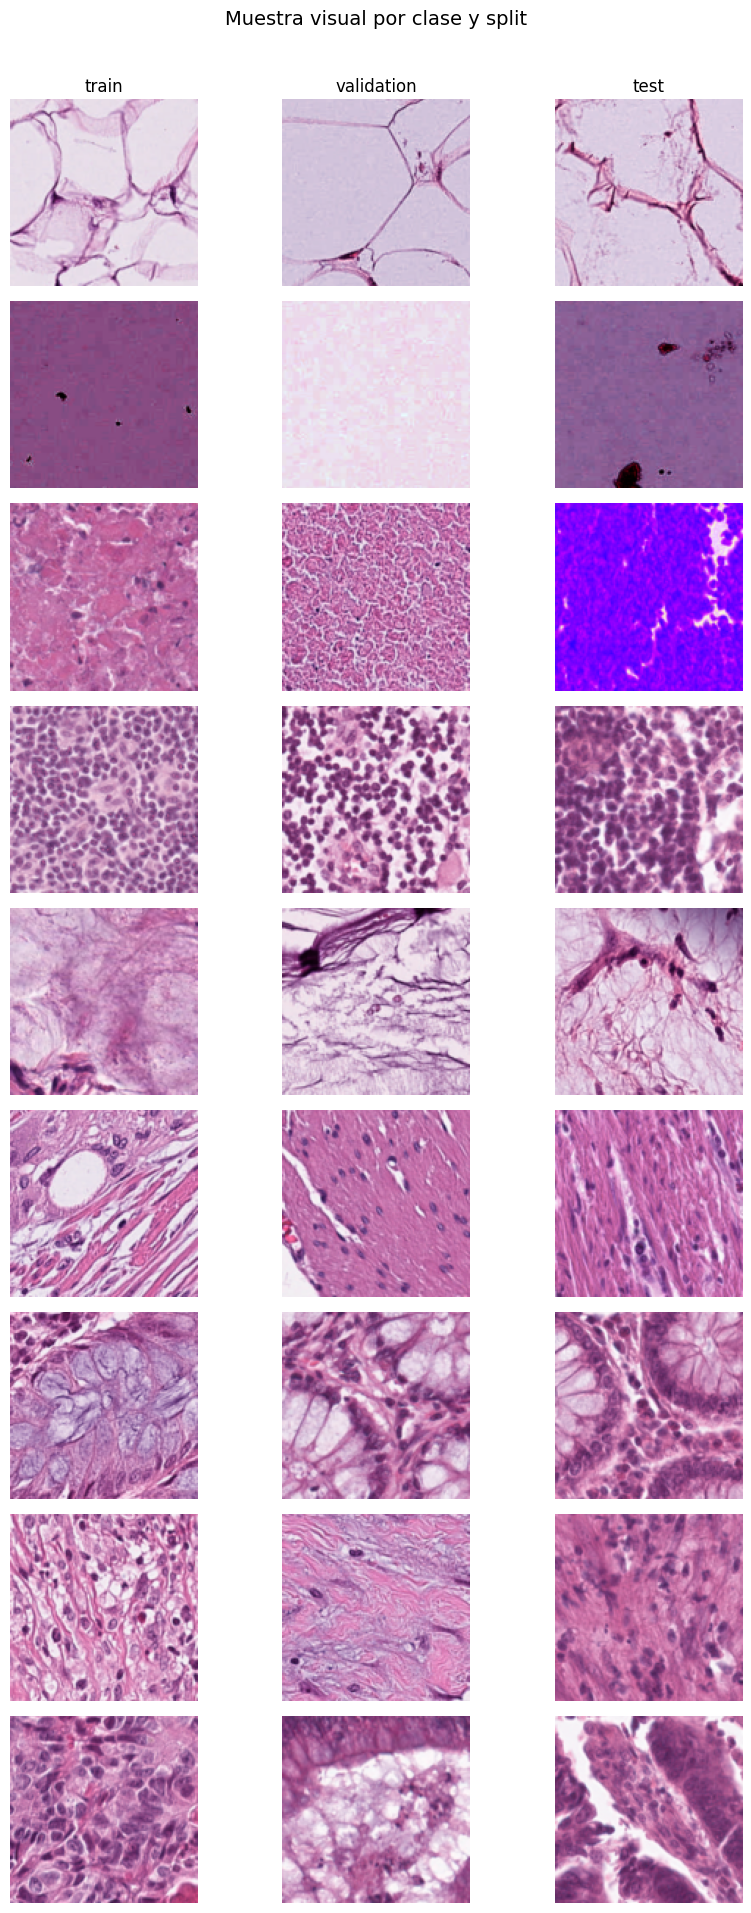

In [12]:
plot_all_classes_across_splits(datasets, class_id_to_name, seed=SEED)


In [13]:
def compute_global_rgb_statistics(dataset, split_name):
    images = dataset.imgs.astype(np.float32)
    channel_names = ["R", "G", "B"]
    rows = []

    for channel_idx, channel_name in enumerate(channel_names):
        values = images[:, :, :, channel_idx].reshape(-1)
        rows.append({
            "split": split_name,
            "channel": channel_name,
            "min": values.min(),
            "p01": np.percentile(values, 1),
            "mean": values.mean(),
            "median": np.median(values),
            "p99": np.percentile(values, 99),
            "max": values.max(),
            "std": values.std(),
        })

    return pd.DataFrame(rows)

global_rgb_stats_df = pd.concat([
    compute_global_rgb_statistics(dataset, split_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

rgb_mean_pivot = global_rgb_stats_df.pivot(index="split", columns="channel", values="mean").reset_index()
rgb_std_pivot = global_rgb_stats_df.pivot(index="split", columns="channel", values="std").reset_index()

rgb_mean_display = rgb_mean_pivot.copy()
rgb_std_display = rgb_std_pivot.copy()
for df in [rgb_mean_display, rgb_std_display]:
    for channel in ["R", "G", "B"]:
        df[channel] = df[channel].round(2)

train_rgb_mean_255 = rgb_mean_pivot[rgb_mean_pivot["split"] == "train"][["R", "G", "B"]].iloc[0].to_numpy()
train_rgb_std_255 = rgb_std_pivot[rgb_std_pivot["split"] == "train"][["R", "G", "B"]].iloc[0].to_numpy()

normalization_stats_df = pd.DataFrame({
    "channel": ["R", "G", "B"],
    "mean_0_255": train_rgb_mean_255,
    "std_0_255": train_rgb_std_255,
    "mean_0_1": train_rgb_mean_255 / 255.0,
    "std_0_1": train_rgb_std_255 / 255.0,
}).round(4)

print("Medias RGB por split")
display(rgb_mean_display)
print("Desviaciones estándar RGB por split")
display(rgb_std_display)
print("Parámetros recomendados de normalización basados solo en train")
display(normalization_stats_df)


Medias RGB por split


channel,split,B,G,R
0,test,180.839996,136.509995,185.350006
1,train,179.979996,135.899994,188.830002
2,validation,180.259995,136.300003,189.070007


Desviaciones estándar RGB por split


channel,split,B,G,R
0,test,43.570000,59.950001,44.000000
1,train,37.919998,52.880001,39.060001
2,validation,37.939999,53.009998,38.980000


Parámetros recomendados de normalización basados solo en train


,channel,mean_0_255,std_0_255,mean_0_1,std_0_1
0,R,188.833801,39.064701,0.7405,0.1532
1,G,135.904602,52.878799,0.5330,0.2074
2,B,179.979797,37.924999,0.7058,0.1487


In [14]:
def compute_image_quality_metrics(dataset, split_name, class_id_to_name):
    images = dataset.imgs.astype(np.float32)
    labels = dataset.labels.reshape(-1).astype(int)
    rows = []

    for idx in range(images.shape[0]):
        image = images[idx]
        gray_like = image.mean(axis=2)
        rows.append({
            "split": split_name,
            "image_index": idx,
            "class_id": labels[idx],
            "class_name": class_id_to_name[labels[idx]],
            "mean_intensity": gray_like.mean(),
            "std_intensity": gray_like.std(),
            "p01_intensity": np.percentile(gray_like, 1),
            "p99_intensity": np.percentile(gray_like, 99),
        })

    return pd.DataFrame(rows)

image_quality_df = pd.concat([
    compute_image_quality_metrics(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

quality_summary_by_split = image_quality_df.groupby("split").agg(
    num_images=("image_index", "count"),
    mean_intensity_mean=("mean_intensity", "mean"),
    mean_intensity_std=("mean_intensity", "std"),
    std_intensity_mean=("std_intensity", "mean"),
    std_intensity_std=("std_intensity", "std"),
).reset_index().round(3)

quality_thresholds = {
    "very_dark_mean": image_quality_df["mean_intensity"].quantile(0.01),
    "very_bright_mean": image_quality_df["mean_intensity"].quantile(0.99),
    "very_low_std": image_quality_df["std_intensity"].quantile(0.01),
    "very_high_std": image_quality_df["std_intensity"].quantile(0.99),
}
quality_thresholds_df = pd.DataFrame([quality_thresholds]).round(3)

image_quality_flags_df = image_quality_df.copy()
image_quality_flags_df["flag_very_dark"] = image_quality_flags_df["mean_intensity"] <= quality_thresholds["very_dark_mean"]
image_quality_flags_df["flag_very_bright"] = image_quality_flags_df["mean_intensity"] >= quality_thresholds["very_bright_mean"]
image_quality_flags_df["flag_low_variability"] = image_quality_flags_df["std_intensity"] <= quality_thresholds["very_low_std"]
image_quality_flags_df["flag_high_variability"] = image_quality_flags_df["std_intensity"] >= quality_thresholds["very_high_std"]

flag_columns = [
    "flag_very_dark",
    "flag_very_bright",
    "flag_low_variability",
    "flag_high_variability",
]
image_quality_flags_df["num_flags"] = image_quality_flags_df[flag_columns].sum(axis=1)

quality_flags_by_split = image_quality_flags_df.groupby("split")[flag_columns + ["num_flags"]].sum().reset_index()
quality_flags_by_class = image_quality_flags_df.groupby(["class_id", "class_name"])[flag_columns + ["num_flags"]].sum().reset_index()

print("Resumen de calidad por split")
display(quality_summary_by_split)
print("Umbrales exploratorios")
display(quality_thresholds_df)
print("Flags por split")
display(quality_flags_by_split)
print("Flags por clase")
display(quality_flags_by_class)


Resumen de calidad por split


,split,num_images,mean_intensity_mean,mean_intensity_std,std_intensity_mean,std_intensity_std
0,test,7180,167.567001,32.800999,31.930000,12.946
1,train,89996,168.238998,26.679001,30.716999,11.738
2,validation,10004,168.544006,26.632999,30.816999,11.697


Umbrales exploratorios


,very_dark_mean,very_bright_mean,very_low_std,very_high_std
0,96.467,231.3,2.334,54.442


Flags por split


,split,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
0,test,14,25,4,159,202
1,train,965,948,954,835,3702
2,validation,93,99,114,78,384


Flags por clase


,class_id,class_name,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
0,0,adipose,0,31,5,53,89
1,1,background,1061,979,1059,81,3180
2,2,debris,10,19,4,128,161
3,3,lymphocytes,0,0,0,410,410
4,4,mucus,1,6,0,71,78
5,5,smooth muscle,0,34,4,14,52
6,6,normal colon mucosa,0,1,0,13,14
7,7,cancer-associated stroma,0,0,0,0,0
8,8,colorectal adenocarcinoma epithelium,0,2,0,302,304


,split,image_index,class_id,class_name,mean_intensity,std_intensity,p01_intensity,p99_intensity,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
9656,train,9656,1,background,69.025002,68.594002,0.000000,162.332993,True,False,False,True,2
56978,train,56978,2,debris,75.862999,64.836998,14.333000,234.332993,True,False,False,True,2
82955,train,82955,1,background,231.792007,2.334000,229.000000,242.000000,False,True,True,False,2
75243,train,75243,1,background,237.052002,2.328000,231.332993,244.332993,False,True,True,False,2
20327,train,20327,1,background,231.822006,2.324000,225.667007,239.000000,False,True,True,False,2
68174,train,68174,1,background,232.134995,2.322000,226.332993,239.000000,False,True,True,False,2
39890,train,39890,1,background,231.787003,2.320000,226.332993,238.667007,False,True,True,False,2
23826,train,23826,1,background,231.938995,2.310000,225.000000,238.000000,False,True,True,False,2
42507,train,42507,1,background,231.334000,2.308000,227.332993,236.667007,False,True,True,False,2
39085,train,39085,1,background,231.742996,2.307000,226.000000,239.000000,False,True,True,False,2


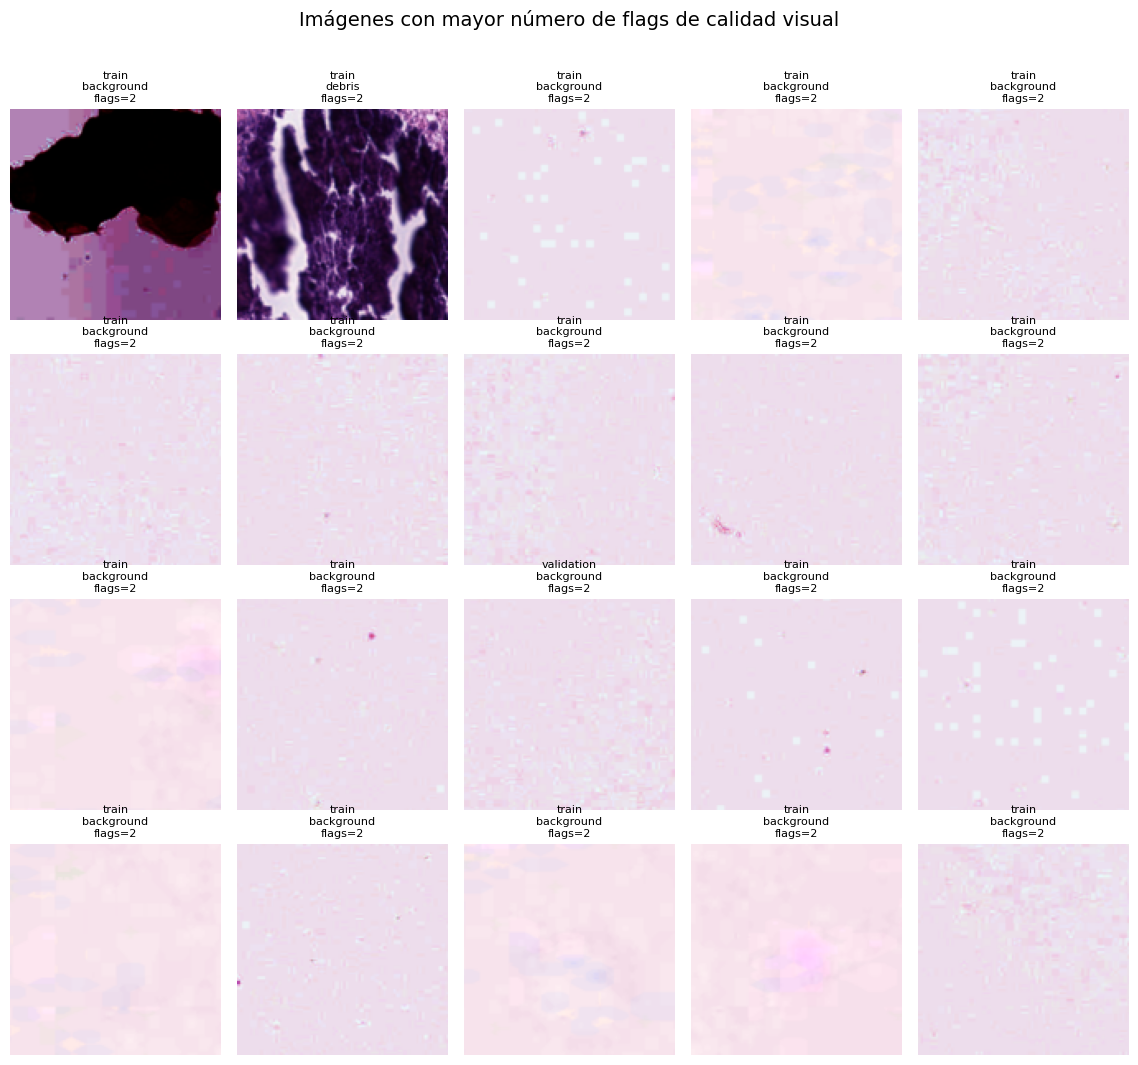

In [15]:
top_flagged_images = image_quality_flags_df[image_quality_flags_df["num_flags"] > 0].sort_values(
    ["num_flags", "std_intensity"], ascending=[False, False]
).head(20)

display(top_flagged_images.round(3))


def plot_selected_quality_cases(selected_df, datasets, title):
    if selected_df.empty:
        print("No hay imágenes seleccionadas para visualizar.")
        return

    n_samples_plot = len(selected_df)
    n_cols = 5
    n_rows = int(np.ceil(n_samples_plot / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.3, n_rows * 2.6))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, selected_df.iterrows()):
        image = datasets[row["split"]].imgs[int(row["image_index"])]
        ax.imshow(image)
        ax.set_title(f"{row['split']}\n{row['class_name']}\nflags={row['num_flags']}", fontsize=8)
        ax.axis("off")

    for ax in axes[n_samples_plot:]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_selected_quality_cases(
    selected_df=top_flagged_images,
    datasets=datasets,
    title="Imágenes con mayor número de flags de calidad visual",
)


In [16]:
def compute_image_hash(image):
    return hashlib.md5(image.tobytes()).hexdigest()


def build_image_hash_table(datasets):
    rows = []
    for split_name, dataset in datasets.items():
        labels = dataset.labels.reshape(-1).astype(int)
        for idx in range(dataset.imgs.shape[0]):
            class_id = labels[idx]
            rows.append({
                "split": split_name,
                "image_index": idx,
                "class_id": class_id,
                "class_name": class_id_to_name[class_id],
                "image_hash": compute_image_hash(dataset.imgs[idx]),
            })
    return pd.DataFrame(rows)

image_hash_df = build_image_hash_table(datasets)

hash_summary_df = pd.DataFrame({
    "total_images": [len(image_hash_df)],
    "unique_hashes": [image_hash_df["image_hash"].nunique()],
    "duplicated_image_count": [image_hash_df.duplicated("image_hash", keep=False).sum()],
})

within_split_duplicate_rows = []
for split_name in ["train", "validation", "test"]:
    split_df = image_hash_df[image_hash_df["split"] == split_name]
    within_split_duplicate_rows.append({
        "split": split_name,
        "num_images": len(split_df),
        "unique_hashes": split_df["image_hash"].nunique(),
        "duplicated_images": split_df.duplicated("image_hash", keep=False).sum(),
    })
within_split_duplicates_df = pd.DataFrame(within_split_duplicate_rows)

cross_split_duplicate_rows = []
for split_a, split_b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    hashes_a = set(image_hash_df[image_hash_df["split"] == split_a]["image_hash"])
    hashes_b = set(image_hash_df[image_hash_df["split"] == split_b]["image_hash"])
    shared_hashes = hashes_a.intersection(hashes_b)
    cross_split_duplicate_rows.append({
        "comparison": f"{split_a}_vs_{split_b}",
        "shared_exact_hashes": len(shared_hashes),
        "has_exact_leakage": len(shared_hashes) > 0,
    })
cross_split_duplicates_df = pd.DataFrame(cross_split_duplicate_rows)

hash_split_summary = image_hash_df.groupby("image_hash").agg(
    num_occurrences=("image_hash", "count"),
    num_splits=("split", "nunique"),
    splits_present=("split", lambda x: sorted(x.unique().tolist())),
).reset_index()

cross_split_leakage_groups = hash_split_summary[hash_split_summary["num_splits"] > 1]

print("Resumen general de hashes")
display(hash_summary_df)
print("Duplicados dentro de cada split")
display(within_split_duplicates_df)
print("Duplicados exactos entre splits")
display(cross_split_duplicates_df)
print("Grupos presentes en más de un split")
display(cross_split_leakage_groups.head(20))


Resumen general de hashes


,total_images,unique_hashes,duplicated_image_count
0,107180,107180,0


Duplicados dentro de cada split


,split,num_images,unique_hashes,duplicated_images
0,train,89996,89996,0
1,validation,10004,10004,0
2,test,7180,7180,0


Duplicados exactos entre splits


,comparison,shared_exact_hashes,has_exact_leakage
0,train_vs_validation,0,False
1,train_vs_test,0,False
2,validation_vs_test,0,False


Grupos presentes en más de un split


,image_hash,num_occurrences,num_splits,splits_present



### Preprocesamiento y DataLoaders

- Transformaciones para ResNet18.
- Conversion a tensor.
- Normalizacion.
- Resize a `224x224` para usar ResNet18 preentrenada.
- DataLoaders de `train`, `val` y `test`.
- Verificacion de un batch.


### Dataloaders

Este bloque prepara los datos para entrenamiento por lotes. En vez de pasar las 89.996 imágenes de una vez, el modelo procesa grupos de 256 imágenes.

Los resultados dan esto:(Despues borramos esto, es para que cuando lo lean lo entiendan mas)

Forma del batch de imágenes: torch.Size([256, 3, 28, 28])

Eso significa: 256 imágenes, 3 canales RGB, alto 28 y ancho 28.

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Forma del batch de imágenes:", images.shape)
print("Forma del batch de etiquetas:", labels.shape)

Forma del batch de imágenes: torch.Size([64, 3, 128, 128])
Forma del batch de etiquetas: torch.Size([64, 1])


### Definción de metricas de validación

Aquí quedan definidas más de dos métricas, así que se cumple la rúbrica. Las más importantes para defender en la presentación son Balanced Accuracy y Macro-F1, porque PathMNIST es multiclase y no conviene depender solo del accuracy.

Accuracy puede verse alto aunque el modelo falle en clases minoritarias. Macro-F1 obliga a mirar el rendimiento promedio por clase.

In [20]:
def calcular_metricas(y_true, y_pred):
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }
    return metricas


metricas_definidas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1"
    ],
    "Uso en el proyecto": [
        "Métrica general de acierto global",
        "Métrica principal para compensar diferencias entre clases",
        "Métrica principal para evaluar desempeño promedio por clase",
        "Métrica complementaria ponderada por cantidad de muestras"
    ]
})

display(metricas_definidas)

,Métrica,Uso en el proyecto
0,Accuracy,Métrica general de acierto global
1,Balanced Accuracy,Métrica principal para compensar diferencias e...
2,Macro-F1,Métrica principal para evaluar desempeño prome...
3,Weighted-F1,Métrica complementaria ponderada por cantidad ...


### Definción del modelo CNN pre-entrenado

Este bloque crea una ResNet18 pre-entrenada y cambia su última capa para que entregue 9 clases, que son las clases de PathMNIST.

Además, congela la mayor parte del modelo y deja entrenables solo layer4 y fc. Eso es fine-tuning parcial: aprovechas características generales ya aprendidas y ajustas la parte final al problema médico.

In [21]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, n_classes)

for name, param in model.named_parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

model = model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Modelo: ResNet18 pre-entrenada")
print("Parámetros totales:", total_params)
print("Parámetros entrenables:", trainable_params)

Modelo: ResNet18 pre-entrenada
Parámetros totales: 11181129
Parámetros entrenables: 8398345


### Función de entrenamiento

Esta función entrena el modelo una vez sobre todo el conjunto de training. Por cada batch calcula predicciones, mide el error, actualiza pesos y guarda las predicciones para calcular métricas.

La función devuelve dos cosas: la pérdida promedio de entrenamiento y las métricas de esa época.

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, desc="Entrenando", leave=False):
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = calcular_metricas(y_true, y_pred)

    return epoch_loss, epoch_metrics

### Función de evalaución

Esta función evalúa el modelo sin modificar sus pesos. Se usa para validation en cada época y para test al final.

La diferencia clave es torch.no_grad(): le dice a PyTorch que no necesita guardar gradientes, por lo que la evaluación consume menos memoria.

In [23]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluando", leave=False):
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = calcular_metricas(y_true, y_pred)

    return epoch_loss, epoch_metrics, np.array(y_true), np.array(y_pred)

### configuración de pérdida, optimizador y entrenamiento

Este bloque entrena la ResNet18 durante 5 épocas. En cada época se entrena con train_loader, se valida con val_loader y se guarda el mejor modelo según Macro-F1 de validación.

Usar Macro-F1 para elegir el mejor modelo es defendible, porque fuerza al modelo a rendir bien en todas las clases y no solo en las más frecuentes.

In [24]:
import os

EPOCHS = 50
LEARNING_RATE = 1e-4


EARLY_STOPPING_PATIENCE = 10

MIN_DELTA = 0.001

early_stopping_counter= 0

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# Con esto, bajamos el learnig rate suavemente hasta casi 0 
# en la ultima epoca, evitando saltar una buena solución mediante el avance de las epocas
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=EPOCHS
)

history = []

best_val_macro_f1 = -1
best_model_path = "outputs/models/best_resnet18_pathmnist_128x128.pth"

for epoch in range(1, EPOCHS + 1):
    print(f"\nÉpoca {epoch}/{EPOCHS}")

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_metrics, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"], 
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"]
    }

    history.append(row)

    print(pd.DataFrame([row]))

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        os.makedirs(os.path.dirname(best_model_path), exist_ok=True)
        torch.save(model.state_dict(), best_model_path)
        print("Nuevo mejor modelo guardado.")
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        print(f"Sin mejora. Patience: {early_stopping_counter}/{EARLY_STOPPING_PATIENCE}")

    scheduler.step() 

    if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping activado.")
        break


history_df = pd.DataFrame(history)
display(history_df)

print(f"\n{'='*50}")
print(f"Best epoch: {history_df['val_macro_f1'].idxmax() + 1}")
print(f"Best Macro-F1: {best_val_macro_f1:.4f}")
print(f"Total epochs trained: {len(history_df)}")


Época 1/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      1    0.226129  0.094593        0.924563      0.968713   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.924224               0.969529        0.924445   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.969016            0.92446         0.968813  
Nuevo mejor modelo guardado.

Época 2/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      2    0.131149  0.067067        0.956065      0.978209   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.956062               0.978414         0.95609   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.978205           0.956086         0.978248  
Nuevo mejor modelo guardado.

Época 3/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      3    0.104783  0.059177        0.964343      0.981208   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.964362               0.981914        0.964416   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.981056           0.964355          0.98119  
Nuevo mejor modelo guardado.

Época 4/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      4    0.090037  0.049347        0.969743      0.984406   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.969787               0.984677        0.969775   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.984522           0.969746         0.984399  
Nuevo mejor modelo guardado.

Época 5/50


...

   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0     48    0.009605  0.021975        0.996689      0.994102   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.996742               0.994062        0.996731   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.994136           0.996689           0.9941  
Sin mejora. Patience: 3/10

Época 49/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0     49    0.009538  0.022296          0.9967      0.994102   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.996734               0.994111        0.996727   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.994193           0.996701         0.994102  
Sin mejora. Patience: 4/10

Época 50/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0     50    0.009606   0.02163        0.996833      0.993802   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.996858               0.993824        0.996842   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.993861           0.996833         0.993801  
Sin mejora. Patience: 5/10


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_balanced_accuracy,val_balanced_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1
0,1,0.226129,0.094593,0.924563,0.968713,0.924224,0.969529,0.924445,0.969016,0.924460,0.968813
1,2,0.131149,0.067067,0.956065,0.978209,0.956062,0.978414,0.956090,0.978205,0.956086,0.978248
2,3,0.104783,0.059177,0.964343,0.981208,0.964362,0.981914,0.964416,0.981056,0.964355,0.981190
3,4,0.090037,0.049347,0.969743,0.984406,0.969787,0.984677,0.969775,0.984522,0.969746,0.984399
4,5,0.082136,0.052431,0.971888,0.982707,0.972104,0.983044,0.972035,0.982977,0.971896,0.982721
5,6,0.074027,0.045521,0.974288,0.985506,0.974419,0.985965,0.974417,0.985676,0.974300,0.985499
6,7,0.067041,0.047179,0.976577,0.985806,0.976681,0.986173,0.976687,0.985940,0.976583,0.985816
7,8,0.063201,0.041814,0.978210,0.986305,0.978241,0.987021,0.978280,0.986300,0.978216,0.986303
8,9,0.058694,0.042155,0.979677,0.985206,0.979688,0.985394,0.979728,0.985319,0.979680,0.985187
9,10,0.054221,0.037521,0.981166,0.987705,0.981171,0.987762,0.981196,0.987940,0.981170,0.987700



Best epoch: 45
Best Macro-F1: 0.9943
Total epochs trained: 50


### Gráficos de entrenamiento y validación

Este bloque genera los gráficos que necesitas para la presentación. El primer gráfico muestra si el error baja; el segundo muestra si las métricas mejoran.

Si train_loss baja pero val_loss sube, hay sobreajuste. Si ambas bajan y las métricas suben, el entrenamiento va bien.

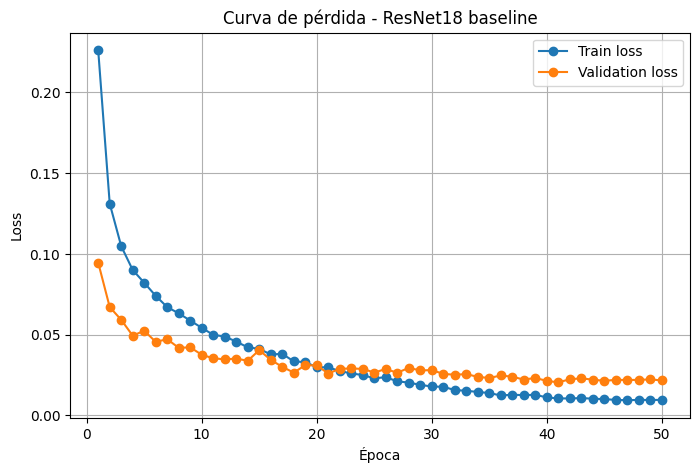

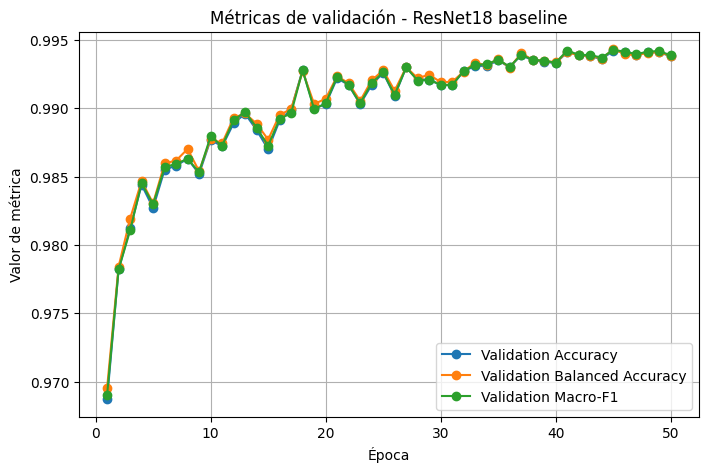

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida - ResNet18 baseline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], marker="o", label="Validation Balanced Accuracy")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro-F1")
plt.xlabel("Época")
plt.ylabel("Valor de métrica")
plt.title("Métricas de validación - ResNet18 baseline")
plt.legend()
plt.grid(True)
plt.show()

### Evaluación final en test

Este bloque carga el mejor modelo encontrado durante validación y lo evalúa una sola vez sobre test.

Esto es importante metodológicamente: test no se usa para tomar decisiones, solo para reportar el rendimiento final.

In [26]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_metrics, y_test_true, y_test_pred = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

test_results_df = pd.DataFrame([{
    "test_loss": test_loss,
    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_weighted_f1": test_metrics["weighted_f1"]
}])

display(test_results_df)

,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,0.205404,0.947354,0.932689,0.927663,0.947452


### Reporte por clase

Este bloque muestra precision, recall y F1-score por cada clase. Es más informativo que mirar solo accuracy.

Para la presentación, de aquí puedes sacar qué clases reconoce mejor la CNN y en cuáles se equivoca más.

In [27]:
report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                      precision    recall  f1-score   support

                             adipose     0.9969    0.9701    0.9833      1338
                          background     1.0000    0.9988    0.9994       847
                              debris     0.8586    0.9676    0.9098       339
                         lymphocytes     0.9526    0.9511    0.9519       634
                               mucus     0.9697    0.9894    0.9794      1035
                       smooth muscle     0.8519    0.8260    0.8388       592
                 normal colon mucosa     0.9475    0.9744    0.9607       741
            cancer-associated stroma     0.7606    0.7696    0.7651       421
colorectal adenocarcinoma epithelium     0.9741    0.9473    0.9605      1233

                            accuracy                         0.9474      7180
                           macro avg     0.9236    0.9327    0.9277      7180
                        weighted avg     0.9481    0.9474    0

### Matriz de confusión

Este bloque genera la matriz de confusión. Sirve para ver visualmente entre qué clases se confunde el modelo.

Este gráfico es muy útil para la presentación, porque conecta el resultado cuantitativo con el problema médico: tejidos visualmente parecidos pueden confundirse más.

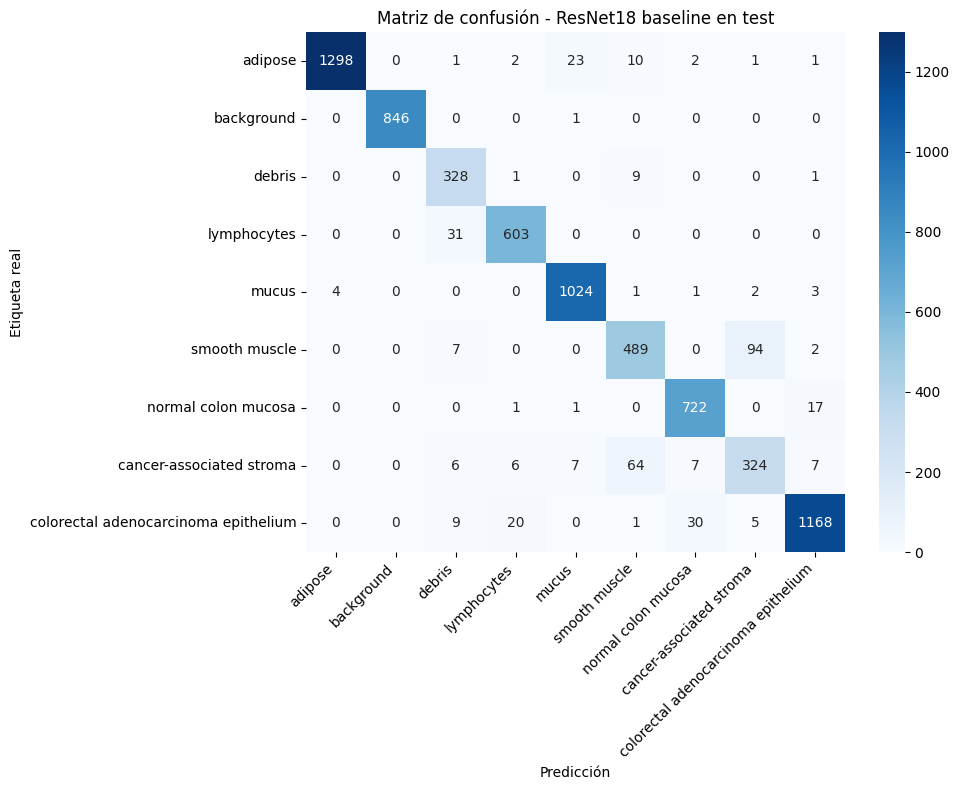

In [28]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - ResNet18 baseline en test")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Recapitulacion de los elementos utilizados.


In [29]:
best_epoch = history_df.loc[history_df["val_macro_f1"].idxmax()]

summary_df = pd.DataFrame({
    "Elemento": [
        "Dataset",
        "Resolución",
        "Diseño experimental",
        "Modelo CNN baseline",
        "Fine-tuning",
        "Métrica principal 1",
        "Métrica principal 2",
        "Mejor época según validation",
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro-F1",
        "Test Weighted-F1"
    ],
    "Resultado": [
        "PathMNIST",
        "28x28 RGB",
        "Hold-out oficial: train / validation / test",
        "ResNet18 pre-entrenada",
        "Parcial: layer4 + fc entrenables",
        "Macro-F1",
        "Balanced Accuracy",
        int(best_epoch["epoch"]),
        round(test_metrics["accuracy"], 4),
        round(test_metrics["balanced_accuracy"], 4),
        round(test_metrics["macro_f1"], 4),
        round(test_metrics["weighted_f1"], 4)
    ]
})

display(summary_df)

,Elemento,Resultado
0,Dataset,PathMNIST
1,Resolución,28x28 RGB
2,Diseño experimental,Hold-out oficial: train / validation / test
3,Modelo CNN baseline,ResNet18 pre-entrenada
4,Fine-tuning,Parcial: layer4 + fc entrenables
5,Métrica principal 1,Macro-F1
6,Métrica principal 2,Balanced Accuracy
7,Mejor época según validation,45
8,Test Accuracy,0.9474
9,Test Balanced Accuracy,0.9327
